In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
import warnings

### Import cleaned data

In [24]:
df = pd.read_csv('../notebooks/data/processed/clean_data.csv')

Show top 5 records

In [59]:
df

,date,product_type,units_demanded,total_revenue,demand_lag_1,demand_lag_7,demand_lag_14,demand_lag_30,rolling_mean_7,rolling_std_7,day_of_week,month,is_weekend
0,2023-03-31,Bathroom,73,21106.09,92,132,100,94,175.142857,111.128197,4,3,0
1,2023-03-31,Bedding,84,23947.81,92,71,73,73,163.714286,115.531690,4,3,0
2,2023-03-31,BlueStar AC,20,5152.10,43,36,28,41,145.285714,123.970042,4,3,0
3,2023-03-31,Children's,69,17996.76,88,50,78,79,122.571429,116.573092,4,3,0
4,2023-03-31,Chocolate,109,33073.26,101,74,60,96,126.571429,115.059198,4,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11082,2024-02-29,Tablet,127,35833.63,255,136,239,145,197.142857,66.611882,3,2,0
11083,2024-02-29,Television,151,39034.21,109,189,189,175,189.714286,73.823470,3,2,0
11084,2024-02-29,Thriller,74,19022.53,105,86,102,85,186.714286,77.193943,3,2,0
11085,2024-02-29,Tools,102,25782.19,120,119,73,117,162.285714,64.744921,3,2,0


In [71]:
cutoff_idx = int(df.shape[0]*0.8)
cutoff_date = df.iloc[cutoff_idx]['date']
train_set = df.loc[:cutoff_idx,:]
test_set = df.loc[cutoff_idx+1:, :]

In [73]:
test_set

,date,product_type,units_demanded,total_revenue,demand_lag_1,demand_lag_7,demand_lag_14,demand_lag_30,rolling_mean_7,rolling_std_7,day_of_week,month,is_weekend
8870,2023-12-24,T-shirt,172,48606.63,176,143,232,176,163.142857,44.681945,6,12,1
8871,2023-12-24,Tablet,206,60639.14,146,127,189,189,161.714286,45.106224,6,12,1
8872,2023-12-24,Television,154,33774.46,166,165,182,129,166.428571,43.293022,6,12,1
8873,2023-12-24,Thriller,103,29747.70,94,42,129,140,161.714286,49.634377,6,12,1
8874,2023-12-24,Tools,81,16765.74,156,106,86,83,148.714286,32.551059,6,12,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11082,2024-02-29,Tablet,127,35833.63,255,136,239,145,197.142857,66.611882,3,2,0
11083,2024-02-29,Television,151,39034.21,109,189,189,175,189.714286,73.823470,3,2,0
11084,2024-02-29,Thriller,74,19022.53,105,86,102,85,186.714286,77.193943,3,2,0
11085,2024-02-29,Tools,102,25782.19,120,119,73,117,162.285714,64.744921,3,2,0


Preparing X and y variables and train test split

In [32]:
# 1. Extract unique dates in sorted chronological order
unique_dates = df['date'].sort_values().unique()

# 2. Compute the 80% cutoff date index
cutoff_idx = int(len(unique_dates) * 0.80)
cutoff_date = unique_dates[cutoff_idx]

print(f"Cutoff Date: {cutoff_date}")

# 3. Create boolean masks directly from product_type_sales_clean
train_mask = df['date'] < cutoff_date
test_mask = df['date'] >= cutoff_date

# 4. Define features (X) and target (y) as pure DataFrames/Series
cols_to_drop = ['date', 'units_demanded', 'total_revenue', 'day_of_week', 'is_weekend']
feature_cols = [col for col in df.columns if col not in cols_to_drop]

X = df[feature_cols]
y = df['units_demanded']

# 5. Split Features (X) and Target (y) using positional masks (.to_numpy() ensures compatibility)
X_train, y_train = X[train_mask.to_numpy()], y[train_mask.to_numpy()]
X_test, y_test = X[test_mask.to_numpy()], y[test_mask.to_numpy()]



print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_test shape : {X_test.shape}  | y_test shape : {y_test.shape}")

Cutoff Date: 2023-12-24
X_train shape: (8843, 8) | y_train shape: (8843,)
X_test shape : (2244, 8)  | y_test shape : (2244,)


In [33]:
X_train.head(5)

,product_type,demand_lag_1,demand_lag_7,demand_lag_14,demand_lag_30,rolling_mean_7,rolling_std_7,month
0,Bathroom,92,132,100,94,175.142857,111.128197,3
1,Bedding,92,71,73,73,163.714286,115.531690,3
2,BlueStar AC,43,36,28,41,145.285714,123.970042,3
3,Children's,88,50,78,79,122.571429,116.573092,3
4,Chocolate,101,74,60,96,126.571429,115.059198,3


In [28]:
# Create Column Transformer with 3 types of transformers
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
         ("StandardScaler", numeric_transformer, num_features),        
    ]
)

C:\Users\Ehtasham\AppData\Local\Temp\ipykernel_16992\3246835917.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes(include="object").columns


In [34]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.fit_transform(X_test)

In [35]:
X_train.shape

(8843, 40)

In [36]:
X_test.shape

(2244, 40)

Create an Evaluate Function to give all metrics after model Training

In [37]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [38]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 30.7349
- Mean Absolute Error: 23.6710
- R2 Score: 0.8413
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 31.4494
- Mean Absolute Error: 24.3363
- R2 Score: 0.8428


Lasso
Model performance for Training set
- Root Mean Squared Error: 34.2236
- Mean Absolute Error: 26.3773
- R2 Score: 0.8032
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 35.1824
- Mean Absolute Error: 26.9395
- R2 Score: 0.8033


Ridge
Model performance for Training set
- Root Mean Squared Error: 30.7567
- Mean Absolute Error: 23.6927
- R2 Score: 0.8411
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 31.4923
- Mean Absolute Error: 24.3367
- R2 Score: 0.8424


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 27.2542
- Mean Absolute Error: 21.0199
- R2 Score: 0.8752
---------

### Result

In [39]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
0,Linear Regression,0.842793
2,Ridge,0.842364
7,CatBoosting Regressor,0.831567
5,Random Forest Regressor,0.829839
3,K-Neighbors Regressor,0.816066
6,XGBRegressor,0.812497
8,AdaBoost Regressor,0.806056
1,Lasso,0.803259
4,Decision Tree,0.666016


#### Linear Regression

In [40]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 84.28


#### Plot y_pred and y_test

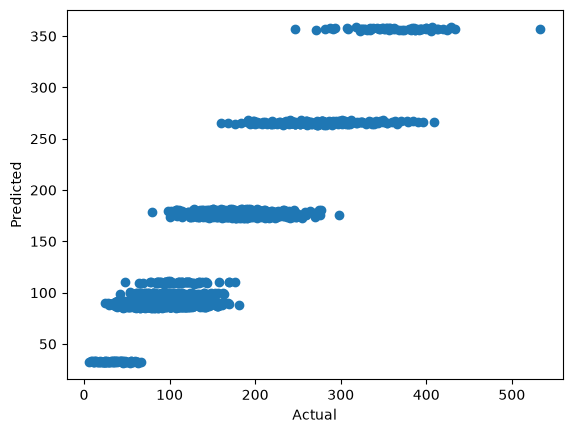

In [41]:
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

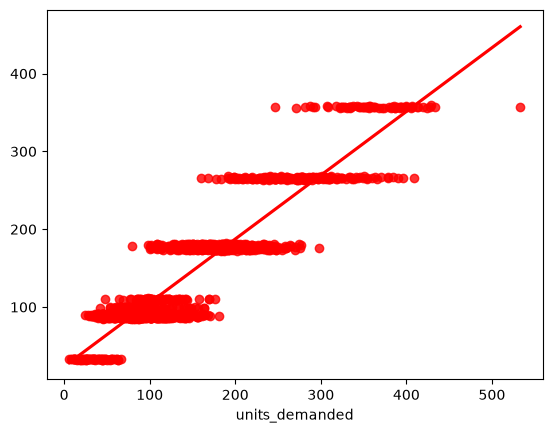

In [42]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red');

##### Difference between Actual and Predicted Values

In [43]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
8843,55,87.054364,-32.054364
8844,84,87.891626,-3.891626
8845,46,31.853450,14.146550
8846,56,88.121943,-32.121943
8847,81,89.127420,-8.127420
...,...,...,...
11082,127,175.873333,-48.873333
11083,151,179.666395,-28.666395
11084,74,90.214221,-16.214221
11085,102,86.712250,15.287750


### Model Performance Comparison

| Model | Train $R^2$ | Test $R^2$ | Test MAE | Test RMSE | Verdict / Diagnosis |
| ----- | ----- | ----- | ----- | ----- | ----- |
| **Linear Regression** | $0.8413$ | **$0.8428$** | **$24.34$** | **$31.45$** | **Best Overall / Production Pick** (Stable, zero overfitting)|
| **Ridge** | $0.8411$ | **$0.8424$** | **$24.34$** | **$31.49$** | **Best Regularized Linear** (Virtually identical to OLS)|
| **CatBoost** | $0.9012$ | **$0.8316$** | **$25.08$** | **$32.55$** | **Best Tree Model** (Competitive, slight generalization gap)|
| **Random Forest** | $0.9759$ | $0.8298$ | $25.04$ | $32.72$ | **Average / Overfitting** (High train $R^2$, lags test)|
| **K-Neighbors** | $0.8752$ | $0.8161$ | $26.36$ | $34.02$ | **Average** (Distance metric diluted by sparse/one-hot dimensions)|
| **XGBRegressor** | $0.9427$ | $0.8125$ | $26.31$ | $34.35$ | **Average / Overfitting** (Memorizing train patterns)|
| **AdaBoost** | $0.8085$ | $0.8061$ | $27.19$ | $34.93$ | **Average / Underfitting** (High bias across both splits)|
| **Lasso** | $0.8032$ | $0.8033$ | $26.94$ | $35.18$ | **Average / Over-penalized** (Zeroed out useful features via L1)|
| **Decision Tree** | $1.0000$ | **$0.6660$** | **$35.46$** | **$45.84$** | **Terrible / Catastrophic Overfitting** (Unconstrained depth memorization)|

---

### Key Engineering Takeaways

* **Linear/Ridge Wins Because Demand is Strongly Autoregressive:**
* As observed in your correlation checks ($r = 0.84$ on lag features), the underlying demand signal is primarily linear.
* Linear Regression and Ridge generalize with $R^2 \approx 0.843$ on unseen test dates without complex hyperparameter tuning.




* **Tree Models Overfit on Default Depth/Leaves:**
* The Decision Tree has a train $R^2$ of $1.0000$ and a test $R^2$ of $0.6660$, showing total memorization.


* Random Forest and XGBoost also overfit (Train $R^2 > 0.94$ vs Test $R^2 \approx 0.81\text{--}0.83$) because default estimators build deep trees that learn sample noise rather than generalizable volume trends.




* **L1 vs L2 Regularization:**
* Ridge preserved the shared signal across correlated lags ($R^2 = 0.8424$).


* Lasso dropped performance to $R^2 = 0.8033$ by zeroing out collinear lag features that were still collectively useful.





---

### Production Recommendation

Select **Linear Regression** or **Ridge Regression** as your final production artifact. They provide the lowest prediction error ($\text{MAE} \approx 24.34$ units), the fastest inference latency, the lowest memory footprint, and zero generalization degradation on unseen future dates.